In [1]:
import sys, os, pygmt, importlib
mod_path = '/home/581/da1339/AFIM/src/AFIM/src'
sys.path.insert(0, mod_path)
from sea_ice_toolbox         import SeaIceToolbox, SeaIceToolboxManager
mod_path = '/home/581/da1339/AFIM/src/mawsons-chest/src'
sys.path.insert(0, mod_path)
from mawsons_tools           import toolbelt
import numpy                 as np
import pandas                as pd
import xarray                as xr
import xesmf                 as xe
import matplotlib.pyplot     as plt
from pathlib                 import Path

In [4]:
import sys
import importlib
for mod in list(sys.modules):
    if mod.startswith("sea_ice_toolbox") or mod.startswith("sea_ice_"):
        del sys.modules[mod]
import sea_ice_cice
import sea_ice_waves
import sea_ice_regridder
import sea_ice_plotter
import sea_ice_classification
import sea_ice_icebergs
import sea_ice_observations
import sea_ice_metrics
import sea_ice_gridwork
import sea_ice_toolbox
importlib.reload(sea_ice_cice)
importlib.reload(sea_ice_waves)
importlib.reload(sea_ice_regridder)
importlib.reload(sea_ice_plotter)
importlib.reload(sea_ice_classification)
importlib.reload(sea_ice_icebergs)
importlib.reload(sea_ice_observations)
importlib.reload(sea_ice_metrics)
importlib.reload(sea_ice_gridwork)
importlib.reload(sea_ice_toolbox)
from sea_ice_toolbox import SeaIceToolbox, SeaIceToolboxManager

# help functions

In [ ]:
F_dt   = "1993-04-24"
D_run  = Path("/g/data/gv90/da1339/cice-dirs/runs/free-slip-waves/history")
F_fmt  = f"iceh.{F_dt}.nc"
P_nc   = D_run / F_fmt
ds     = xr.open_dataset(P_nc)

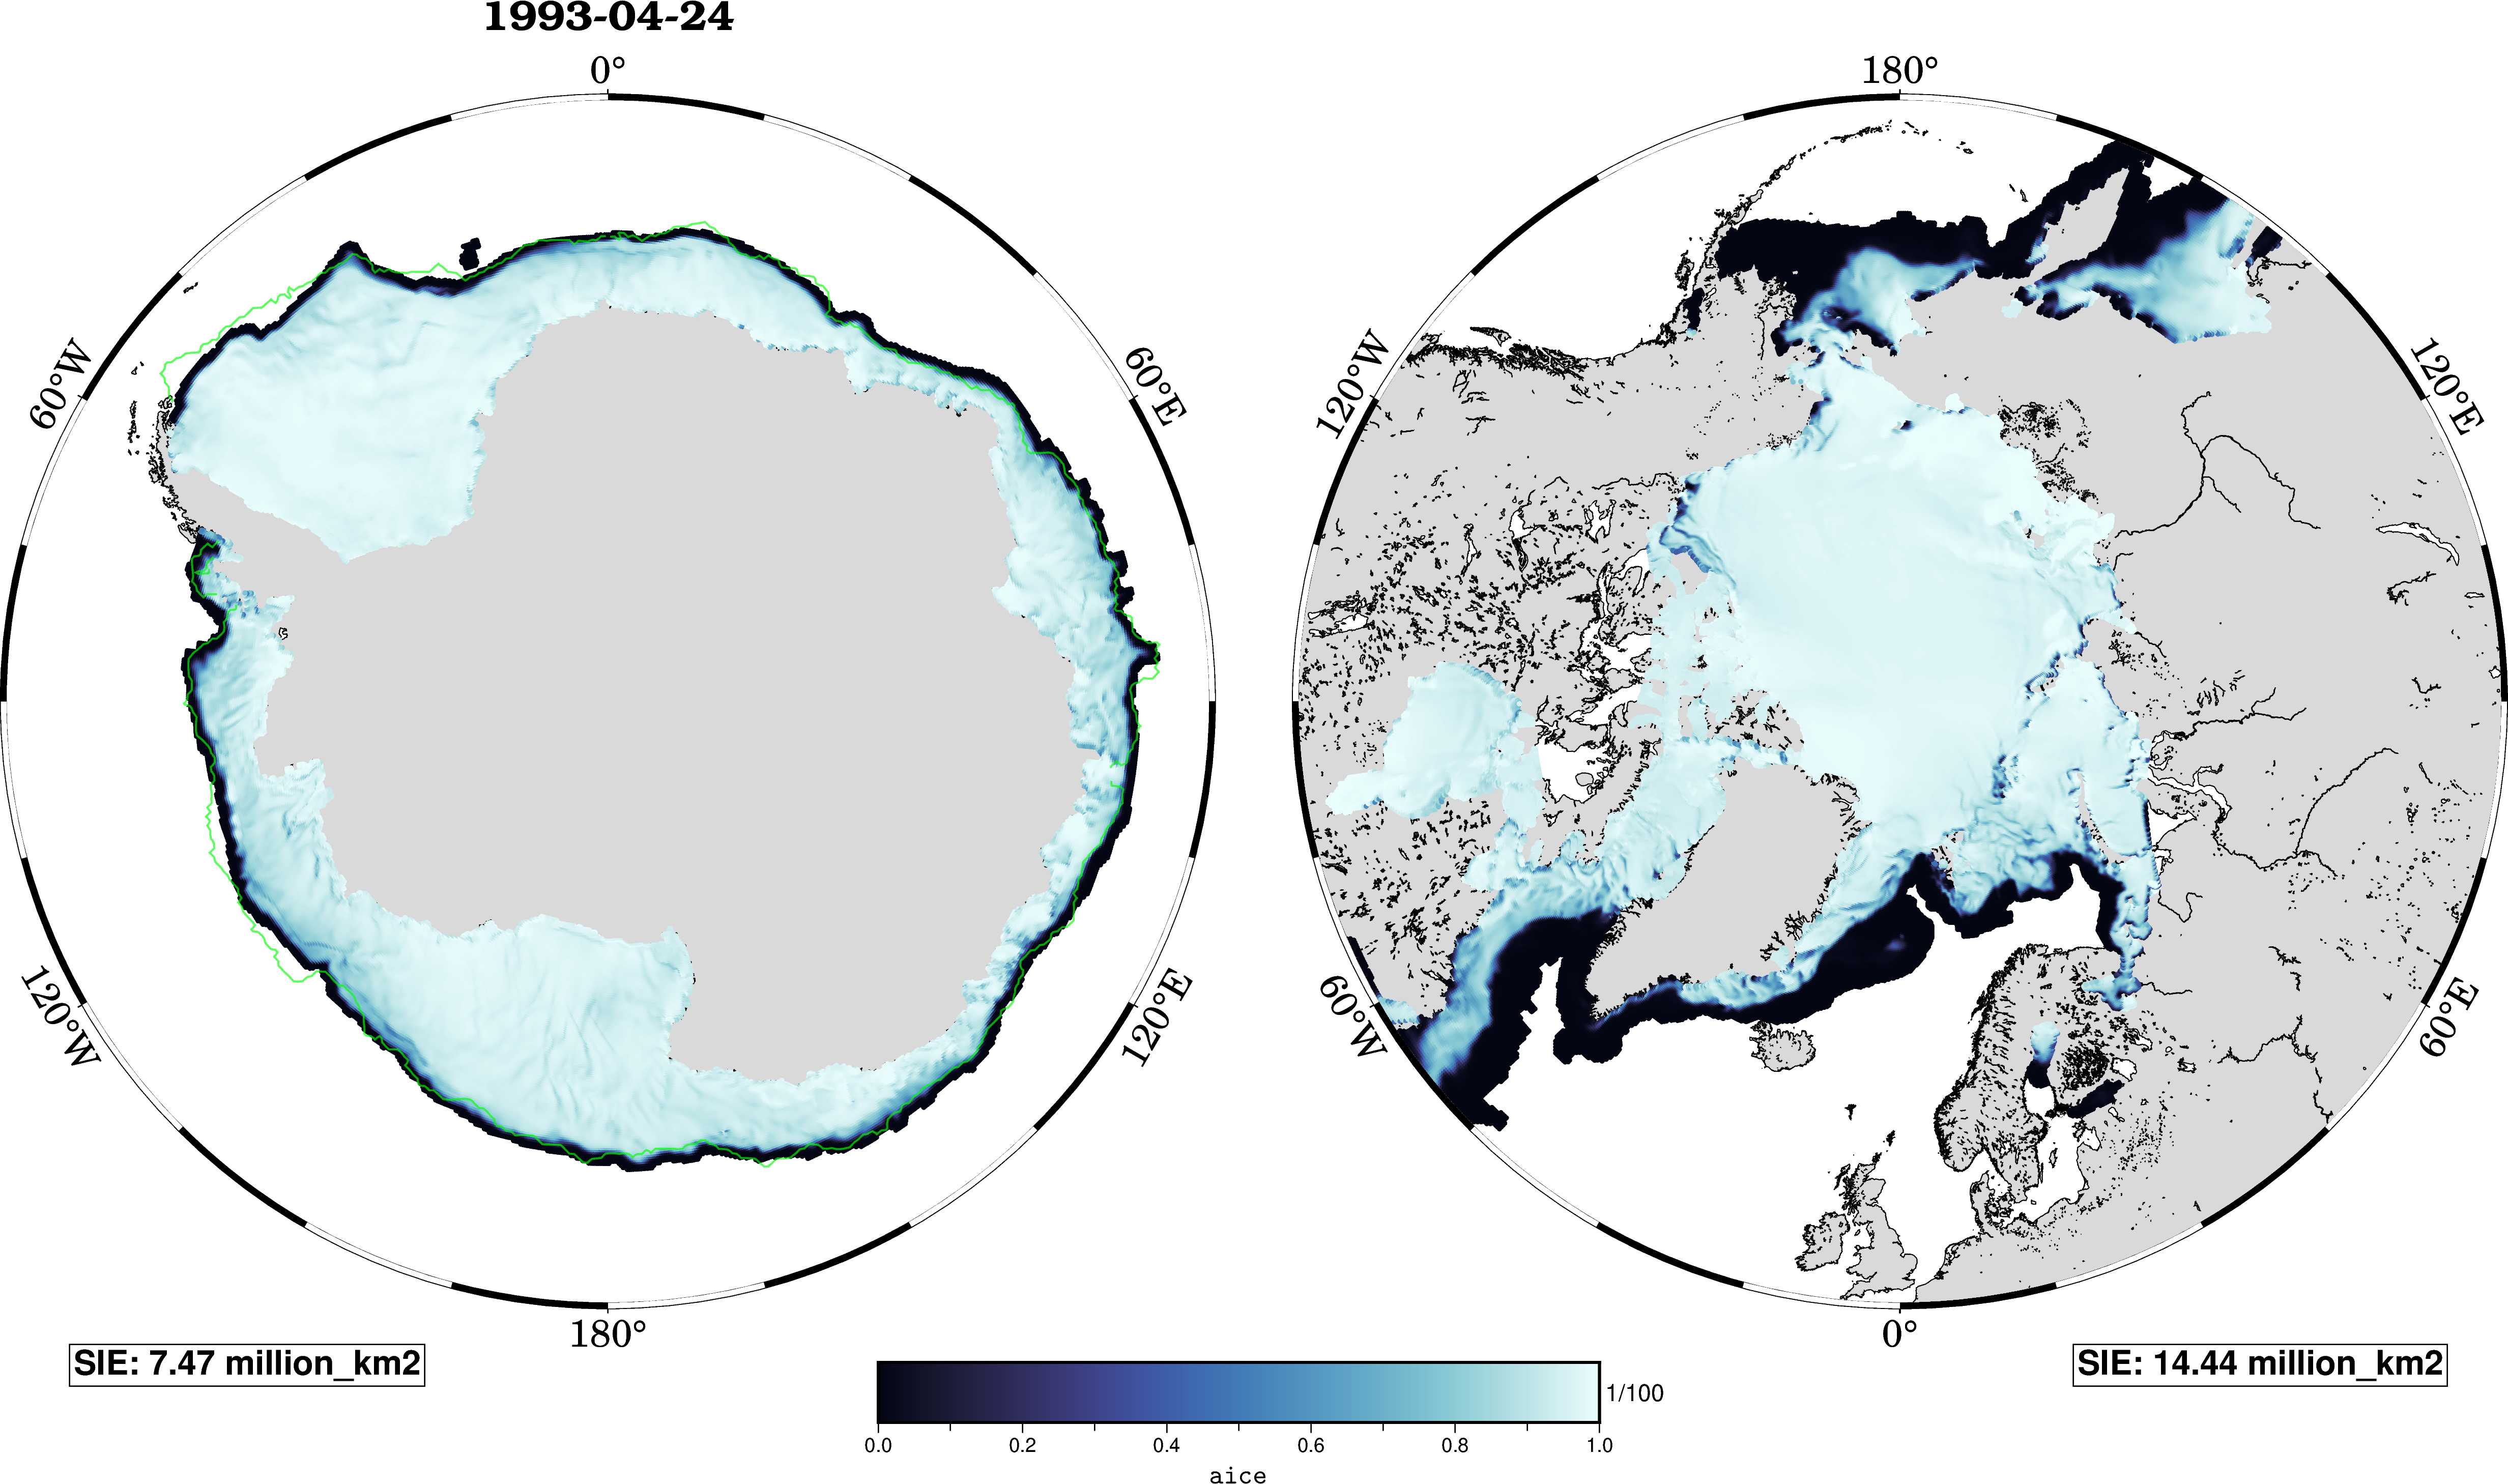

In [76]:
da            = ds['aice']
da_plt        = pygmt_cice_da_prep(da)
dt_str        = cice_corrected_datestr(ds)
ext           = compute_cice_ice_extent(ds, threshold=0.15, area_units_out="million_km2")
sh_txt        = format_cice_ice_extent_label(ext["south"], hemisphere="SH", units="million_km2", threshold=ext["threshold"], precision=2)
nh_txt        = format_cice_ice_extent_label(ext["north"], hemisphere="NH", units="million_km2", threshold=ext["threshold"], precision=2)
D_nsidc_sh    = Path("/g/data/gv90/da1339/SeaIce/NSIDC/G02202_V4/south/daily")
P_nsidc_sh    = find_nsidc_daily_file(dt_str, D_nsidc_sh, hemisphere="south")
nsidc_sh      = load_nsidc_day(P_nsidc_sh)
nsidc_sh_segs = nsidc_sic_contour_segments(nsidc_sh, threshold=0.15, hemisphere="south", lon_wrap="0-360",)
fig           = pygmt.Figure()
with pygmt.config(FONT_TITLE           = "20p,Bookman-Demi",
                  FONT_ANNOT_PRIMARY   = "18p,NewCenturySchlbk-Roman",
                  FONT_ANNOT_SECONDARY = "18p,NewCenturySchlbk-Bold",
                  FONT_LABEL           = "18p,NewCenturySchlbk-Bold",
                  COLOR_FOREGROUND     = "black",):
    pygmt_basemap(fig, frame=["af",f"+t{dt_str}"])
    pygmt.makecpt(cmap="cmocean/ice", series=[0,1])
    fig.plot(x=da_plt["lon"], y=da_plt["lat"], style="c0.08c", fill=da_plt['z'], cmap=True)
    plot_nsidc_segments(fig, nsidc_sh_segments, pen="0.8p,green@35")
    fig.text(position="BL", text=sh_txt, justify="CM", offset="4c/-1c", font="16p,Helvetica-Bold,black", fill="white@35", pen="0.5p,black", no_clip=True)
    fig.shift_origin(xshift="1w+1.5c")
    pygmt_basemap(fig, region=[0,360,50,90], projection="S0/90/20c", frame=("af",))
    fig.plot(x=da_plt["lon"], y=da_plt["lat"], style="c0.08c", fill=da_plt['z'], cmap=True)
    fig.text(position="BR", text=nh_txt, justify="CM", offset="-4c/-1c", font="16p,Helvetica-Bold,black", fill="white@35", pen="0.5p,black", no_clip=True)
fig.colorbar(position="JBC+w12c/1c+mc+h+o-11c/1c", frame=["xaf+l@[\\texttt{aice}@[","y+l1/100"], cmap=True)
fig.show()

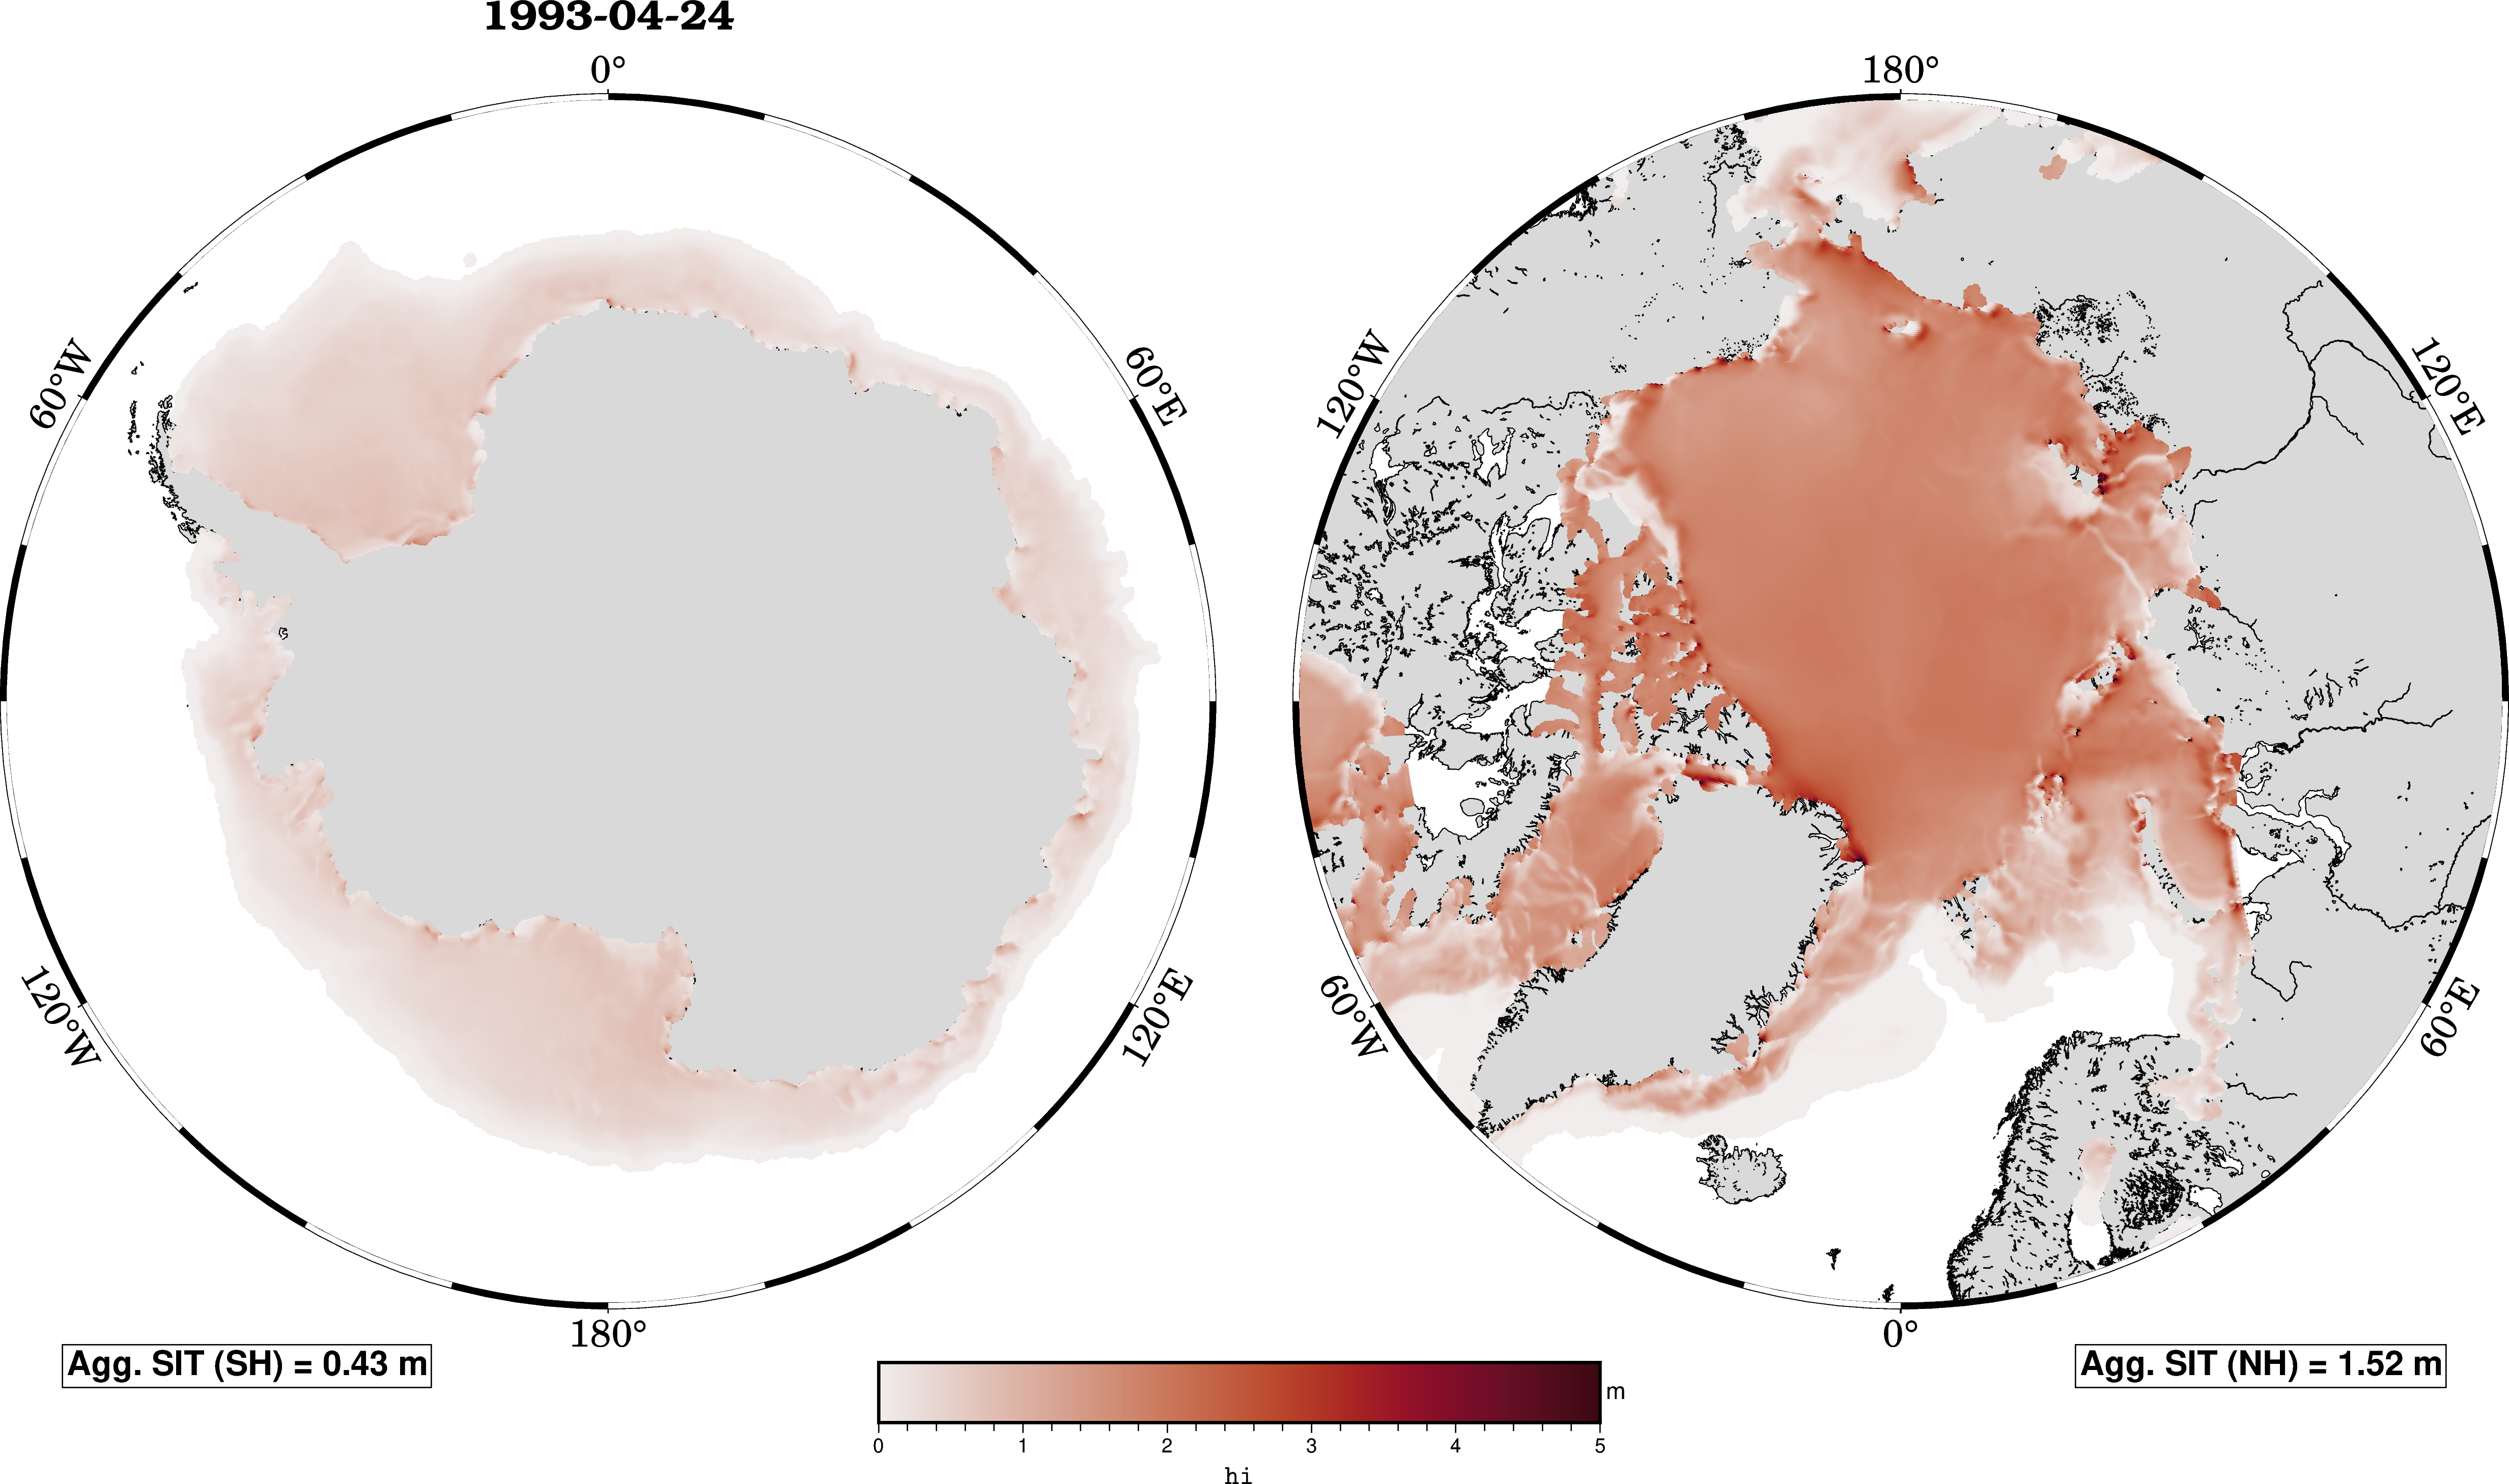

In [83]:
da     = ds["hi"]
da_plt = pygmt_cice_da_prep(da)
sit_stats = compute_cice_aggregate_sit(ds)
sh_txt = format_cice_aggregate_sit_label(sit_stats["south"]["SIT"], hemisphere="SH", units=sit_stats["SIT_units"])
nh_txt = format_cice_aggregate_sit_label(sit_stats["north"]["SIT"], hemisphere="NH", units=sit_stats["SIT_units"])
fig = pygmt.Figure()
with pygmt.config(FONT_TITLE="20p,Bookman-Demi",
                  FONT_ANNOT_PRIMARY="18p,NewCenturySchlbk-Roman",
                  FONT_ANNOT_SECONDARY="18p,NewCenturySchlbk-Bold",
                  FONT_LABEL="18p,NewCenturySchlbk-Bold",
                  COLOR_FOREGROUND="black"):
    pygmt_basemap(fig, frame=["af", f"+t{dt_str}"])
    pygmt.makecpt(cmap="cmocean/amp", series=[0, 5])
    fig.plot(x=da_plt["lon"], y=da_plt["lat"], style="c0.08c", fill=da_plt["z"], cmap=True)
    fig.text(position="BL", text=sh_txt, justify="CM", offset="4c/-1c", font="16p,Helvetica-Bold,black", fill="white@35", pen="0.5p,black", no_clip=True)
    fig.shift_origin(xshift="1w+1.5c")
    pygmt_basemap(fig, region=[0, 360, 60, 90], projection="S0/90/20c", frame=("af",))
    fig.plot(x=da_plt["lon"], y=da_plt["lat"], style="c0.08c", fill=da_plt["z"], cmap=True)
    fig.text(position="BR", text=nh_txt, justify="CM", offset="-4c/-1c", font="16p,Helvetica-Bold,black", fill="white@35", pen="0.5p,black", no_clip=True)
fig.colorbar(position="JBC+w12c/1c+mc+h+o-11c/1c", frame=["xaf+l@[\\texttt{hi}@[", "y+lm"], cmap=True)
fig.show()

# CAWCR spectral wave regridding

In [6]:
D_cfg
= Path.home() / "AFIM" / "src" / "AFIM" / "src" / "JSONs"
ice_type   = 'FI' 
dt0, dtN   = '1993-01-01', '1994-12-31'
hemisphere = 'south'
sim_names  = ["waves", "LD-static-Cs2p5e-4"]
BorC2T     = ['Tc', 'Tc']
P_log      = Path.home() / "logs" / f"waves_setup.log"
mgr        = SeaIceToolboxManager(P_log = P_log)
tb         = mgr.get_toolbox(P_json         = D_cfg / "sea_ice_free-slip.json",
                             sim_name       = sim_names[0], 
                             dt0_str        = dt0,
                             dtN_str        = dtN,
                             list_of_BorC2T = BorC2T[0],
                             ice_type       = ice_type,
                             hemisphere     = hemisphere)

2026-04-03 04:27:09,920 - INFO - log file connected: /home/581/da1339/logs/waves_setup.log
2026-04-03 04:27:09,961 - INFO - Dask Client Connected
  Dashboard      : /proxy/8787/status
  Threads        : 4
  Threads/Worker : [1, 1, 1, 1]
  Total Memory   : 64.00 GB

2026-04-03 04:27:09,962 - INFO - hemisphere initialised: SH
2026-04-03 04:27:09,963 - INFO - reading /g/data/gv90/da1339/afim_output/waves/ice_diag.d to construct /g/data/gv90/da1339/afim_output/waves/ice_in_AFIM_subset_waves.json
2026-04-03 04:27:09,997 - INFO - --- SeaIceToolbox Summary ---
2026-04-03 04:27:09,999 - INFO - Simulation Name     : waves
2026-04-03 04:27:10,000 - INFO - Analysis Start Date : 1993-01-01
2026-04-03 04:27:10,001 - INFO - Analysis End Date   : 1994-12-31
2026-04-03 04:27:10,002 - INFO - grid file           : /g/data/gv90/da1339/grids/ACCESS-OM3-025_Cgrid.nc
2026-04-03 04:27:10,003 - INFO - landmask file       : /g/data/gv90/da1339/grids/ACCESS-OM3-025_kmt.nc
2026-04-03 04:27:10,005 - INFO - Using 

In [ ]:
P_wave = tb.prepare_cawcr_wave_month(1993, 1, overwrite=True, overwrite_weights=True, k = 5, power = 2.5, radius_km = 1000)

2026-04-03 04:27:26,786 - INFO - Opening local CAWCR spectra: /g/data/gv90/da1339/afim_input/CAWCR/org/ww3.199301_spec.nc
/home/581/da1339/AFIM/src/AFIM/src/sea_ice_waves.py:115: UserWarning: The specified chunks separate the stored chunks along dimension "station" starting at index 512. This could degrade performance. Instead, consider rechunking after loading.
  return xr.open_dataset(p_local, chunks=chunks)
2026-04-03 04:27:33,600 - INFO - Opening grid geometry: /g/data/gv90/da1339/grids/ACCESS-OM3-025_Cgrid.nc
2026-04-03 04:27:41,442 - INFO - station_lon dims: ('time', 'station'), (745, 919)
2026-04-03 04:27:41,443 - INFO - station_lat dims: ('time', 'station'), (745, 919)
2026-04-03 04:27:41,454 - INFO - Creating wave sparse weights: /g/data/gv90/da1339/grids/weights/map_CAWCRstations_to_ACCESS-OM3-025_idw_k8.npz
2026-04-03 04:27:41,670 - INFO - Wave weight chunk 1/4: 100000 target cells
2026-04-03 04:27:41,831 - INFO - Wave weight chunk 2/4: 100000 target cells
2026-04-03 04:27:4

In [11]:
dsA = xr.open_dataset("/g/data/gv90/da1339/afim_input/CAWCR/CAWCR_efreq_for_CICE6_199301.nc")
dsB = xr.open_dataset("/g/data/gv90/da1339/afim_input/CAWCR/attempt1/CAWCR_efreq_for_CICE6_199301.nc")

In [10]:
print(ds1)
print(ds2)

<xarray.Dataset> Size: 134GB
Dimensions:    (time: 745, nfreq: 29, nj: 1080, ni: 1440)
Coordinates:
  * time       (time) datetime64[ns] 6kB 1993-01-01 ... 1993-02-01
  * nfreq      (nfreq) float32 116B 0.035 0.0385 0.04235 ... 0.4589 0.5047
  * nj         (nj) int32 4kB 0 1 2 3 4 5 6 ... 1074 1075 1076 1077 1078 1079
  * ni         (ni) int32 6kB 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
Data variables:
    efreq      (time, nfreq, nj, ni) float32 134GB ...
    TLON       (nj, ni) float32 6MB ...
    TLAT       (nj, ni) float32 6MB ...
    wavefreq   (nfreq) float32 116B ...
    dwavefreq  (nfreq) float32 116B ...
Attributes:
    title:    CAWCR wave spectra remapped to native CICE grid
    source:   CAWCR monthly station spectra, directionally integrated and reg...
    note:     efreq written with dims (time,nfreq,nj,ni) for compatibility wi...
<xarray.Dataset> Size: 134GB
Dimensions:    (time: 745, nfreq: 29, nj: 1080, ni: 1440)
Coordinates:
  * time       (time) datetime64[ns

Comparison: time=1993-01-01T09, freq_idx=19, f=0.21406 Hz
bias = -1.911956e-01
MAE  = 2.474986e-01
RMSE = 3.640218e-01
corr = 0.857547


/jobfs/164503000.gadi-pbs/ipykernel_929169/111670234.py:134: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m0 = axes[0, 0].pcolormesh(LON2, LAT2, A2, shading="auto", vmin=vmin_main, vmax=vmax_main)
/jobfs/164503000.gadi-pbs/ipykernel_929169/111670234.py:141: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  m1 = axes[0, 1].pcolormesh(LON2, LAT2, B2, shading="auto", vmin=vmin_main, vmax=vmax_main)
/jobfs/164503000.gadi-pbs/ipykernel_929169/111670234.py:148: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasin

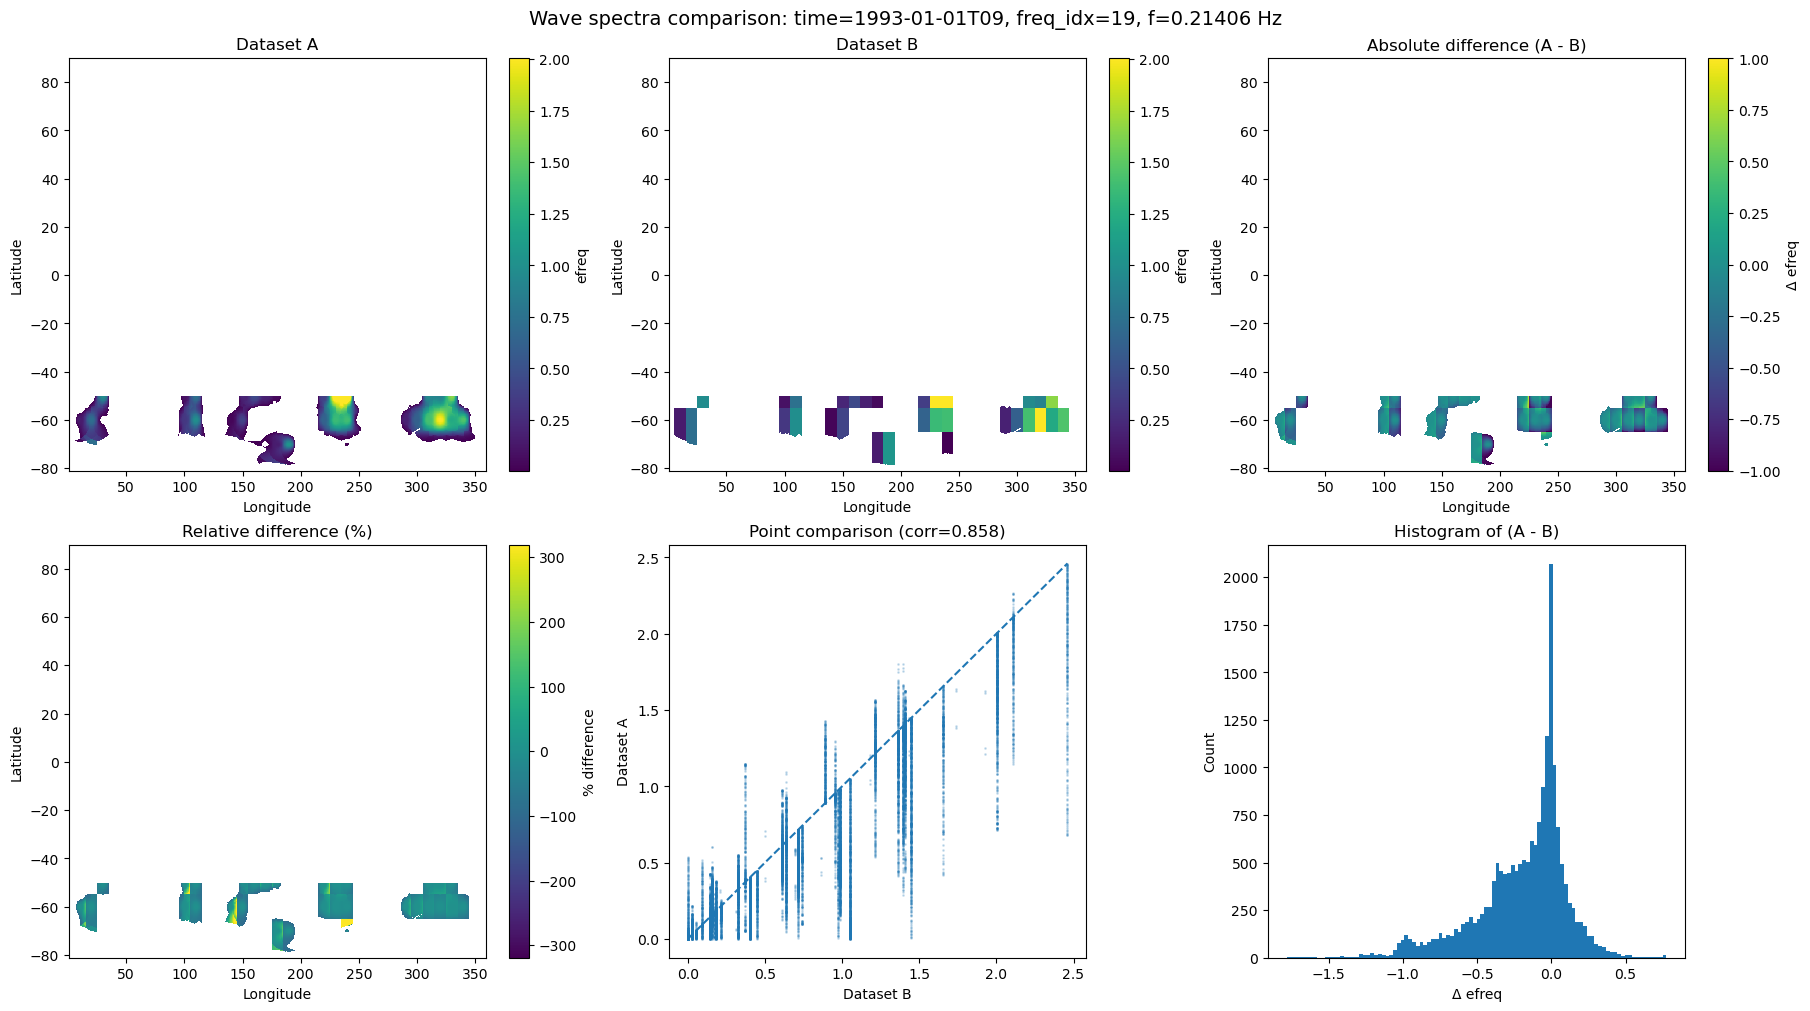

In [18]:
# Jupyter cell: graphical comparison of two gridded wave-spectra datasets
# Assumes you already have two xarray Datasets in memory:
#   dsA, dsB
# and each contains:
#   efreq(time, nfreq, nj, ni), TLON(nj,ni), TLAT(nj,ni), wavefreq(nfreq), dwavefreq(nfreq)
# -----------------------------
# user controls
# -----------------------------
time_index   = 10  # integer time index to compare
freq_index   = 19         # integer frequency index to compare if mode="slice"
mode         = "slice"   # "slice" or "integrated"
lat_min      = -90        # optional spatial crop
lat_max      = -50
robust_pct   = (2, 98)    # percentile range for plotting main fields
diff_pct     = (2, 98)    # percentile range for absolute-difference plot
eps          = 1e-12      # protects relative-difference division

# Optional coarsening for quicker preview on a huge grid:
# set to 1 for no coarsening, or e.g. 2, 4, 8
coarsen_factor = 2

# -----------------------------
# basic checks
# -----------------------------
assert "efreq" in dsA and "efreq" in dsB, "Both datasets must contain 'efreq'"
assert dsA.efreq.dims == dsB.efreq.dims, "efreq dims do not match"
assert dsA.sizes["time"] == dsB.sizes["time"], "time dimension mismatch"
assert dsA.sizes["nfreq"] == dsB.sizes["nfreq"], "nfreq dimension mismatch"
assert dsA.sizes["nj"] == dsB.sizes["nj"], "nj dimension mismatch"
assert dsA.sizes["ni"] == dsB.sizes["ni"], "ni dimension mismatch"


# -----------------------------
# harmonise coordinates if needed
# -----------------------------
# Prefer wavefreq if present, otherwise nfreq coordinate itself
freq_coord_A = dsA["wavefreq"] if "wavefreq" in dsA else dsA["nfreq"]
freq_coord_B = dsB["wavefreq"] if "wavefreq" in dsB else dsB["nfreq"]

# -----------------------------
# build fields lazily
# -----------------------------
if mode == "slice":
    A = dsA["efreq"].isel(time=time_index, nfreq=freq_index)
    B = dsB["efreq"].isel(time=time_index, nfreq=freq_index)
    title_suffix = (
        f"time={np.datetime_as_string(dsA.time.values[time_index], unit='h')}, "
        f"freq_idx={freq_index}, "
        f"f={float(freq_coord_A.isel(nfreq=freq_index).values):.5f} Hz"
    )

elif mode == "integrated":
    # frequency-integrated energy density: sum(efreq * df)
    if "dwavefreq" in dsA and "dwavefreq" in dsB:
        A = (dsA["efreq"].isel(time=time_index) * dsA["dwavefreq"]).sum("nfreq")
        B = (dsB["efreq"].isel(time=time_index) * dsB["dwavefreq"]).sum("nfreq")
    else:
        # fallback if dwavefreq absent
        A = dsA["efreq"].isel(time=time_index).sum("nfreq")
        B = dsB["efreq"].isel(time=time_index).sum("nfreq")
    title_suffix = f"time={np.datetime_as_string(dsA.time.values[time_index], unit='h')}, frequency-integrated"

else:
    raise ValueError("mode must be either 'slice' or 'integrated'")

# -----------------------------
# spatial mask / crop
# -----------------------------
lat = dsA["TLAT"]
lon = dsA["TLON"]

mask = (lat >= lat_min) & (lat <= lat_max)

A = A.where(mask)
B = B.where(mask)

# Optional coarsening for speed / readability
if coarsen_factor > 1:
    A = A.coarsen(nj=coarsen_factor, ni=coarsen_factor, boundary="trim").mean()
    B = B.coarsen(nj=coarsen_factor, ni=coarsen_factor, boundary="trim").mean()
    lat_plot = lat.coarsen(nj=coarsen_factor, ni=coarsen_factor, boundary="trim").mean()
    lon_plot = lon.coarsen(nj=coarsen_factor, ni=coarsen_factor, boundary="trim").mean()
else:
    lat_plot = lat
    lon_plot = lon

# Differences
D_abs = A - B
D_rel = 100.0 * D_abs / xr.where(np.abs(B) > eps, np.abs(B), np.nan)

# -----------------------------
# compute only the small 2D products we need
# -----------------------------
A2, B2, D2, R2, LAT2, LON2 = A.compute(), B.compute(), D_abs.compute(), D_rel.compute(), lat_plot.compute(), lon_plot.compute()

# -----------------------------
# helper for percentile-based color limits
# -----------------------------
def finite_percentiles(da, p=(2, 98)):
    vals = da.values[np.isfinite(da.values)]
    if vals.size == 0:
        return (0.0, 1.0)
    return np.nanpercentile(vals, p)

vmin_main, vmax_main = finite_percentiles(xr.concat([A2, B2], dim="tmp"), robust_pct)
vmin_diff, vmax_diff = finite_percentiles(np.abs(D2), diff_pct)
vlim_rel = np.nanpercentile(np.abs(R2.values[np.isfinite(R2.values)]), 98) if np.isfinite(R2.values).any() else 1.0

# -----------------------------
# summary stats
# -----------------------------
rmse = float(np.sqrt(np.nanmean((D2.values)**2)))
mae  = float(np.nanmean(np.abs(D2.values)))
bias = float(np.nanmean(D2.values))

valid = np.isfinite(A2.values) & np.isfinite(B2.values)
if np.count_nonzero(valid) > 1:
    corr = float(np.corrcoef(A2.values[valid].ravel(), B2.values[valid].ravel())[0, 1])
else:
    corr = np.nan

print(f"Comparison: {title_suffix}")
print(f"bias = {bias:.6e}")
print(f"MAE  = {mae:.6e}")
print(f"RMSE = {rmse:.6e}")
print(f"corr = {corr:.6f}")

# -----------------------------
# plotting
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)

# Dataset A
m0 = axes[0, 0].pcolormesh(LON2, LAT2, A2, shading="auto", vmin=vmin_main, vmax=vmax_main)
axes[0, 0].set_title("Dataset A")
axes[0, 0].set_xlabel("Longitude")
axes[0, 0].set_ylabel("Latitude")
fig.colorbar(m0, ax=axes[0, 0], label="efreq")

# Dataset B
m1 = axes[0, 1].pcolormesh(LON2, LAT2, B2, shading="auto", vmin=vmin_main, vmax=vmax_main)
axes[0, 1].set_title("Dataset B")
axes[0, 1].set_xlabel("Longitude")
axes[0, 1].set_ylabel("Latitude")
fig.colorbar(m1, ax=axes[0, 1], label="efreq")

# Absolute difference
m2 = axes[0, 2].pcolormesh(LON2, LAT2, D2, shading="auto", vmin=-vmax_diff, vmax=vmax_diff)
axes[0, 2].set_title("Absolute difference (A - B)")
axes[0, 2].set_xlabel("Longitude")
axes[0, 2].set_ylabel("Latitude")
fig.colorbar(m2, ax=axes[0, 2], label="Δ efreq")

# Relative difference
m3 = axes[1, 0].pcolormesh(LON2, LAT2, R2, shading="auto", vmin=-vlim_rel, vmax=vlim_rel)
axes[1, 0].set_title("Relative difference (%)")
axes[1, 0].set_xlabel("Longitude")
axes[1, 0].set_ylabel("Latitude")
fig.colorbar(m3, ax=axes[1, 0], label="% difference")

# Scatter comparison
axes[1, 1].scatter(B2.values[valid], A2.values[valid], s=1, alpha=0.2)
mn = np.nanmin([A2.values[valid], B2.values[valid]])
mx = np.nanmax([A2.values[valid], B2.values[valid]])
axes[1, 1].plot([mn, mx], [mn, mx], linestyle="--")
axes[1, 1].set_title(f"Point comparison (corr={corr:.3f})")
axes[1, 1].set_xlabel("Dataset B")
axes[1, 1].set_ylabel("Dataset A")

# Histogram of differences
axes[1, 2].hist(D2.values[np.isfinite(D2.values)].ravel(), bins=100)
axes[1, 2].set_title("Histogram of (A - B)")
axes[1, 2].set_xlabel("Δ efreq")
axes[1, 2].set_ylabel("Count")

fig.suptitle(f"Wave spectra comparison: {title_suffix}", fontsize=14)
plt.show()

# waves diff fig

In [ ]:
D_cfg      = Path.home() / "AFIM" / "src" / "AFIM" / "src" / "JSONs"
ice_type   = 'FI' 
dt0, dtN   = '1993-01-01', '1994-12-31'
hemisphere = 'south'
sim_names  = ["waves", "LD-static-Cs2p5e-4"]
BorC2T     = ['Tc', 'Tc']
P_log      = Path.home() / "logs" / f"waves_setup.log"
mgr        = SeaIceToolboxManager(P_log = P_log)
tb         = mgr.get_toolbox(P_json         = D_cfg / "sea_ice_free-slip.json",
                             sim_name       = sim_names[0], 
                             dt0_str        = dt0,
                             dtN_str        = dtN,
                             list_of_BorC2T = BorC2T[0],
                             ice_type       = ice_type,
                             hemisphere     = hemisphere)
SO_waves     = tb.load_cice_zarr(slice_hem=True)
FI_waves     = tb.load_classified_ice()
mets_waves   = tb.load_computed_metrics()
static_waves = tb.load_static(slice_hem=True)
tb           = mgr.get_toolbox(P_json         = D_cfg / "sea_ice_free-slip.json",
                               sim_name       = sim_names[1], 
                               dt0_str        = dt0,
                               dtN_str        = dtN,
                               list_of_BorC2T = BorC2T[1],
                                ice_type       = ice_type,
                             hemisphere     = hemisphere)
SO_static   = tb.load_cice_zarr(slice_hem=True)
FI_static   = tb.load_classified_ice()
mets_static = tb.load_computed_metrics()
# do the differenceing on one time slice
FId      = FI_waves["FI_mask"] - FI_static["FI_mask"]
FId.name = "FI_diff"
FId      = FId.drop_vars(['ni','time'])

In [ ]:
# prepare figure
region     = [30, 80, -71, -64]
fig_size   = 20 #cm
MC         = tb.get_meridian_center_from_geographic_extent(region)
proj_str   = tb.hemisphere_dict['projection'].format(MC=MC, size=fig_size)
cmap       = tb.pygmt_dict['FIP_diff']
# --- pre-slice once ---
t_i        = 200
SO_hs      = SO_waves['wave_sig_ht'].isel(time=t_i)
FIw        = FI_waves["FI_mask"].isel(time=t_i)
FIs        = FI_static["FI_mask"].isel(time=t_i)
FId0       = FId.isel(time=t_i)
F2_abs     = np.hypot(SO_waves['F2E'].isel(time=0), SO_waves['F2N'].isel(time=0))
# For binary masks, only plot the nonzero cells
plt_waves  = tb.pygmt_da_prep(FIw, mask_zero=True)
plt_static = tb.pygmt_da_prep(FIs, mask_zero=True)
plt_F2     = tb.pygmt_da_prep(F2_abs, mask_zero=True)
plt_hs     = tb.pygmt_da_prep(SO_hs, mask_zero=True)
# For the difference field, only plot changed cells
plt_diff   = tb.pygmt_da_prep(FId0, mask_zero=True)
# --- create figure ---
fig        = pygmt.Figure()
with pygmt.config(FONT_TITLE           = "18p,Bookman-Demi",
                  FONT_ANNOT_PRIMARY   = "16p,NewCenturySchlbk-Roman",
                  FONT_ANNOT_SECONDARY = "16p,NewCenturySchlbk-Bold",
                  FONT_LABEL           = "16p,NewCenturySchlbk-Bold",
                  COLOR_FOREGROUND     = "black",):
    tb.pygmt_base_layer(fig, region, proj_str, title="waves")
    pygmt.makecpt(cmap="cmocean/amp", series=[0,5])
    fig.plot(x=plt_hs["lon"], y=plt_hs["lat"], style="c0.08c", fill=plt_hs['z'], cmap=True)
    fig.colorbar(position="JBC+w12c/0.45c+mc+h+o0c/1c", frame=["xaf+l@[H_s@[","y+lm"], cmap=True)
    fig.plot(x=plt_waves["lon"], y=plt_waves["lat"], style="s0.08c", fill="green")
    fig.shift_origin(xshift="1w+1.5c")
    tb.pygmt_base_layer(fig, region, proj_str, title="waves - no_waves")
    fig.plot(x=plt_diff["lon"], y=plt_diff["lat"], fill=plt_diff["z"], style="s0.25c", cmap=cmap)
    fig.colorbar(position="JBC+w12c/0.45c+mc+h+o0c/1c", frame=["xaf+lFI difference"], cmap=cmap)
    fig.shift_origin(xshift="1.75w+1c")
    tb.pygmt_base_layer(fig, region, proj_str, title="no_waves")
    pygmt.makecpt(cmap="cmocean/amp", series=[0,25])
    fig.plot(x=plt_F2["lon"], y=plt_F2["lat"], style="c0.08c", fill=plt_F2['z'], cmap=True)
    fig.colorbar(position="JBC+w12c/0.45c+mc+h+o0c/1c", frame=["xaf+l@[|F_2|@["], cmap=True)
    fig.plot(x=plt_static["lon"], y=plt_static["lat"], style="s0.08c", fill="blue")
fig.show()